# BCI-FedAdapt with Riemannian Manifold Integration

**Enhancement over base notebook:** Riemannian geometry is woven into three stages:
1. **Preprocessing** — SPD covariance manifold alignment (`RiemannianAlignment`) replaces flat Euclidean alignment
2. **Federated Aggregation** — Geometric mean on the SPD manifold (`riemannian_mean`) for quality-weighted model averaging
3. **Quality Scoring** — Riemannian distance between client gradients used as an additional diversity score

Datasets: BCI-IV 2a (9 subjects, 4-class MI) and BCI-IV 2b (9 subjects, 2-class MI)

In [1]:
# 1. Install dependencies
import subprocess, sys
def pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + list(a))
pip('moabb', 'mne', 'scikit-learn', 'torch', 'tqdm', 'matplotlib', 'seaborn', 'scipy', 'pyriemann')
print('Install complete')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.1/279.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 11.6 MB/s eta 0:00:00
Install complete


In [2]:
# 2. Imports
import warnings, copy, random, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy.signal import butter, filtfilt, iirnotch
from scipy.linalg import logm, expm, sqrtm
import moabb
from moabb.datasets import BNCI2014_001, BNCI2014_004
from moabb.paradigms import MotorImagery
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Riemannian geometry
from pyriemann.estimation import Covariances
from pyriemann.utils.mean import mean_riemann
from pyriemann.utils.distance import distance_riemann
from pyriemann.utils.geodesic import geodesic_riemann

moabb.set_log_level('WARNING')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('/mnt/user-data/outputs', exist_ok=True)
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
# 3. Config — BCI-IV 2a
CFG_2A = dict(
    dataset_name = 'BCI-IV 2a',
    sfreq=250, tmin=0.0, tmax=4.0, fmin=4.0, fmax=40.0,
    n_classes=4, n_channels=22,
    notch_freq=50.0, apply_car=True,
    # Riemannian alignment flags
    apply_riemann_align=True,   # NEW: SPD-manifold alignment
    apply_ea=False,             # disable flat EA when Riemannian is on
    ea_eps=1e-6, norm_epochs=True,
    window_size=500, step_size=125,
    F1=16, D=2, F2=32, dropout=0.4,
    n_heads=4, attn_dp=0.4, tcn_filters=32, tcn_kernels=4, tcn_dp=0.3,
    local_epochs=10, batch_size=64, lr=3e-3, wd=1e-4,
    grad_clip=1.0, label_smoothing=0.05, eta_min=1e-5,
    aug_prob=0.5, aug_noise_std=0.01,
    num_rounds=30, proximal_mu=0.02, scaffold_lr=3e-3, momentum_beta=0.9,
    # BCI-FedAdapt quality weights
    qa_alpha=0.35, qa_beta=0.35, qa_gamma=0.15, qa_riemann=0.15,  # NEW: Riemannian diversity term
    qa_temperature=0.5,
    personal_epochs=40, personal_lr=5e-4, personal_wd=1e-5,
    # Riemannian aggregation
    use_riemann_agg=True,       # NEW: geodesic model averaging
    riemann_agg_layers=['fc'],  # layers to aggregate on SPD manifold
)
print('CFG_2A ready')

# Config — BCI-IV 2b
CFG_2B = dict(
    dataset_name='BCI-IV 2b',
    sfreq=250, tmin=0.0, tmax=4.0, fmin=8.0, fmax=30.0,
    n_classes=2, n_channels=3,
    apply_car=True,
    apply_riemann_align=True,
    apply_ea=False,
    ea_eps=1e-6, norm_epochs=True,
    window_size=500, step_size=125,
    F1=8, D=2, F2=16, dropout=0.35,
    n_heads=2, attn_dp=0.3, tcn_filters=16, tcn_kernels=4, tcn_dp=0.2,
    local_epochs=10, batch_size=64, lr=3e-3, wd=1e-4,
    grad_clip=1.0, label_smoothing=0.1, eta_min=1e-5,
    aug_prob=0.5, aug_noise_std=0.01,
    num_rounds=30, proximal_mu=0.02, scaffold_lr=3e-3, momentum_beta=0.9,
    qa_alpha=0.35, qa_beta=0.35, qa_gamma=0.15, qa_riemann=0.15,
    qa_temperature=0.5,
    personal_epochs=40, personal_lr=5e-4, personal_wd=1e-5,
    use_riemann_agg=True,
    riemann_agg_layers=['fc'],
)
print('CFG_2B ready')

CFG_2A ready
CFG_2B ready


## Preprocessing + Riemannian Manifold Alignment

Classical *Euclidean alignment* whitens the mean covariance.  
**Riemannian alignment** instead maps each trial's covariance to the tangent space at the Fréchet mean on the SPD manifold, providing geometry-aware whitening that respects the curved nature of covariance matrices.

In [4]:
# ── Riemannian alignment helpers ──────────────────────────────────────────────

def spd_matrix(X: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Compute regularised SPD covariance: (1/T) X X^T + eps*I."""
    C, T = X.shape
    cov = (X @ X.T) / T
    cov += eps * np.eye(C)
    return cov.astype(np.float64)


def riemannian_alignment(X: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """
    Riemannian Alignment (RA) — geometry-aware inter-session/inter-subject
    alignment on the SPD manifold.

    Steps:
      1. Compute per-trial SPD covariance matrices C_i.
      2. Compute the Riemannian (Fréchet) mean M = argmin sum d_R(C_i, M)^2.
      3. Whitening transform: W = M^{-1/2}.
      4. Apply W to each trial: X_i_aligned = W @ X_i.

    Args:
        X:   (N, C, T) float array — epochs
        eps: regularisation for numerical stability

    Returns:
        X_aligned: (N, C, T) float32 array
    """
    N, C, T = X.shape
    # Step 1 — compute SPD covariance per trial
    covs = np.stack([spd_matrix(X[i].astype(np.float64), eps) for i in range(N)])  # (N,C,C)
    # Step 2 — Riemannian mean via pyriemann (iterative fixed-point)
    M = mean_riemann(covs, tol=1e-8, maxiter=100)  # (C,C)
    # Step 3 — whitening: M^{-1/2}
    eigvals, eigvecs = np.linalg.eigh(M)
    eigvals = np.maximum(eigvals, eps)
    W = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T  # (C,C)
    # Step 4 — apply whitening
    X_aligned = np.einsum('ij,njt->nit', W, X.astype(np.float64)).astype(np.float32)
    return X_aligned


def apply_car(X: np.ndarray) -> np.ndarray:
    return X - X.mean(axis=1, keepdims=True)


def euclidean_alignment(X: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Fallback: original flat-space EA."""
    N, C, T = X.shape
    R = np.zeros((C, C), dtype=np.float64)
    for i in range(N):
        xi = X[i].astype(np.float64)
        R += xi @ xi.T / T
    R /= N
    R += eps * np.eye(C)
    eigvals, eigvecs = np.linalg.eigh(R)
    eigvals = np.maximum(eigvals, eps)
    R_inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T
    return np.einsum('ij,njt->nit', R_inv_sqrt, X).astype(np.float32)


def normalize_epochs(X: np.ndarray) -> np.ndarray:
    mu  = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True) + 1e-8
    return (X - mu) / std


def preprocess(X: np.ndarray, cfg: dict) -> np.ndarray:
    """Full preprocessing pipeline with optional Riemannian alignment."""
    if cfg.get('apply_car', True):
        X = apply_car(X)
    if cfg.get('apply_riemann_align', False):
        X = riemannian_alignment(X, eps=cfg.get('ea_eps', 1e-6))
    elif cfg.get('apply_ea', True):
        X = euclidean_alignment(X, eps=cfg.get('ea_eps', 1e-6))
    if cfg.get('norm_epochs', True):
        X = normalize_epochs(X)
    return X


def make_windows(X: np.ndarray, y: np.ndarray, window_size: int, step_size: int):
    N, C, T = X.shape
    wins, labels = [], []
    for i in range(N):
        for start in range(0, T - window_size + 1, step_size):
            wins.append(X[i, :, start:start + window_size])
            labels.append(y[i])
    return np.array(wins, dtype=np.float32), np.array(labels, dtype=np.int64)


def soft_vote_predict(model: nn.Module, X_trials: np.ndarray,
                      window_size: int, step_size: int) -> np.ndarray:
    model.eval()
    preds = []
    with torch.no_grad():
        for trial in X_trials:
            C, T = trial.shape
            windows = []
            for s in range(0, T - window_size + 1, step_size):
                windows.append(trial[:, s:s + window_size])
            wins_t = torch.tensor(np.array(windows), dtype=torch.float32).to(DEVICE)
            probs  = F.softmax(model(wins_t), dim=1).mean(0)
            preds.append(probs.argmax().item())
    return np.array(preds)


print('Riemannian preprocessing + window helpers defined')

Riemannian preprocessing + window helpers defined


In [5]:
# 5. Load and preprocess dataset
def load_and_preprocess(cfg: dict) -> Tuple[dict, int, object]:
    name = cfg.get('dataset_name', 'BCI-IV 2a')
    align_tag = 'Riemannian' if cfg.get('apply_riemann_align') else 'Euclidean'
    print(f'Loading {name} [{align_tag} alignment] ...')
    if '2a' in name or '001' in name:
        dataset = BNCI2014_001()
    else:
        dataset = BNCI2014_004()
    paradigm = MotorImagery(
        n_classes=cfg['n_classes'], fmin=cfg['fmin'], fmax=cfg['fmax'],
        tmin=cfg['tmin'], tmax=cfg['tmax'], resample=cfg['sfreq'])
    X, y, meta = paradigm.get_data(dataset=dataset)
    le    = LabelEncoder()
    y_enc = le.fit_transform(y)
    print(f'  Raw shape: {X.shape}  Classes: {list(le.classes_)}')
    cdata = {}
    for cid, subj in enumerate(sorted(meta['subject'].unique())):
        mask  = (meta['subject'] == subj).values
        Xs, ys = preprocess(X[mask].astype(np.float32), cfg), y_enc[mask].astype(np.int64)
        Xtr, Xte, ytr, yte = train_test_split(
            Xs, ys, test_size=0.2, stratify=ys, random_state=SEED)
        cdata[cid] = dict(X_train=Xtr, X_test=Xte, y_train=ytr, y_test=yte)
        print(f'  Client {cid:02d}: train={len(ytr)}  test={len(yte)}')
    n_times = X.shape[-1]
    return cdata, n_times, le.classes_

print('load_and_preprocess defined')

load_and_preprocess defined


## ATCNet Architecture

In [6]:
# 6. ATCNet architecture (unchanged)
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=4, dilation=1, dp=0.3):
        super().__init__()
        self.ks, self.dil = kernel_size, dilation
        self.conv1    = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation)
        self.conv2    = nn.Conv1d(out_ch, out_ch, kernel_size, dilation=dilation)
        self.bn1      = nn.BatchNorm1d(out_ch); self.bn2 = nn.BatchNorm1d(out_ch)
        self.act      = nn.ELU(); self.drop = nn.Dropout(dp)
        self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def _pad(self, x):
        total = self.dil * (self.ks - 1)
        return F.pad(x, (total // 2, total - total // 2))
    def forward(self, x):
        T = x.size(2); res = self.residual(x)
        h = self.drop(self.act(self.bn1(self.conv1(self._pad(x))[:, :, :T])))
        h = self.drop(self.act(self.bn2(self.conv2(self._pad(h))[:, :, :T])))
        return h + res

class ATCNet(nn.Module):
    def __init__(self, n_classes, n_channels, n_times, F1=16, D=2, F2=32, dp=0.4,
                 n_heads=4, attn_dp=0.4, tcn_filters=32, tcn_kernels=4, tcn_dp=0.3):
        super().__init__()
        self.temporal  = nn.Sequential(
            nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False), nn.BatchNorm2d(F1))
        self.spatial   = nn.Sequential(
            nn.Conv2d(F1, D*F1, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(D*F1), nn.ELU(), nn.AvgPool2d((1, 4)), nn.Dropout(dp))
        self.separable = nn.Sequential(
            nn.Conv2d(D*F1, D*F1, (1, 16), padding=(0, 8), groups=D*F1, bias=False),
            nn.Conv2d(D*F1, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1, 8)), nn.Dropout(dp))
        with torch.no_grad():
            _x = torch.zeros(1, 1, n_channels, n_times)
            self.T_feat = self.separable(self.spatial(self.temporal(_x))).shape[-1]
        self.attn_norm = nn.LayerNorm(F2)
        self.mha       = nn.MultiheadAttention(F2, n_heads, dropout=attn_dp, batch_first=True)
        self.attn_drop = nn.Dropout(attn_dp)
        self.tcn1      = TCNBlock(F2, tcn_filters, tcn_kernels, dilation=1, dp=tcn_dp)
        self.tcn2      = TCNBlock(tcn_filters, tcn_filters, tcn_kernels, dilation=2, dp=tcn_dp)
        self.out_norm  = nn.LayerNorm(tcn_filters)
        self.fc        = nn.Linear(tcn_filters, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.separable(self.spatial(self.temporal(x)))
        x = x.squeeze(2).transpose(1, 2)
        res = x
        x, _ = self.mha(self.attn_norm(x), self.attn_norm(x), self.attn_norm(x))
        x = self.attn_drop(x) + res
        x = x.transpose(1, 2)
        x = self.tcn2(self.tcn1(x))
        return self.fc(self.out_norm(x.mean(dim=2)))

def make_model(cfg: dict) -> ATCNet:
    return ATCNet(cfg['n_classes'], cfg['n_channels'], cfg['window_size'],
                  F1=cfg['F1'], D=cfg['D'], F2=cfg['F2'], dp=cfg['dropout'],
                  n_heads=cfg['n_heads'], attn_dp=cfg['attn_dp'],
                  tcn_filters=cfg['tcn_filters'], tcn_kernels=cfg['tcn_kernels'],
                  tcn_dp=cfg['tcn_dp']).to(DEVICE)

_m = make_model(CFG_2A)
_x = torch.randn(4, CFG_2A['n_channels'], CFG_2A['window_size']).to(DEVICE)
print(f'ATCNet output: {_m(_x).shape}')
print(f'Params       : {sum(p.numel() for p in _m.parameters()):,}')

ATCNet output: torch.Size([4, 4])
Params       : 24,676


## Riemannian Manifold Utilities for Federated Aggregation

Three novel utilities introduced here:

| Utility | Role |
|---|---|
| `params_to_spd` | Lifts a flat weight vector to the SPD manifold via outer product |
| `riemannian_weighted_mean_spd` | Compute weighted Fréchet mean on SPD manifold for aggregation |
| `riemannian_gradient_diversity` | Measure pairwise geodesic distance between client gradient covariances |

The **geometric aggregation** replaces flat FedAvg for the classifier head layers, ensuring weight updates stay on the manifold of symmetric positive-definite matrices.

In [7]:
# ── Riemannian manifold utilities for federated aggregation ───────────────────

def params_to_spd(vec: np.ndarray, eps: float = 1e-4) -> np.ndarray:
    """
    Lift a flat parameter vector to a symmetric positive-definite (SPD) matrix
    via outer product: M = (v v^T) / ||v||^2 + eps*I.
    This creates a rank-1 SPD approximation of the weight geometry.
    """
    v = vec.astype(np.float64)
    norm_sq = float(v @ v) + 1e-12
    M = np.outer(v, v) / norm_sq
    M += eps * np.eye(len(v))
    return M


def log_map_spd(M: np.ndarray, S: np.ndarray) -> np.ndarray:
    """
    Riemannian logarithmic map: project S onto the tangent space at M.
    Log_M(S) = M^{1/2} logm(M^{-1/2} S M^{-1/2}) M^{1/2}
    """
    M_half     = sqrtm(M).real
    M_inv_half = np.linalg.inv(M_half)
    inner = M_inv_half @ S @ M_inv_half
    inner = (inner + inner.T) / 2  # symmetrise for numerics
    return M_half @ logm(inner).real @ M_half


def exp_map_spd(M: np.ndarray, V: np.ndarray) -> np.ndarray:
    """
    Riemannian exponential map: move from M along tangent V.
    Exp_M(V) = M^{1/2} expm(M^{-1/2} V M^{-1/2}) M^{1/2}
    """
    M_half     = sqrtm(M).real
    M_inv_half = np.linalg.inv(M_half)
    inner = M_inv_half @ V @ M_inv_half
    return M_half @ expm(inner).real @ M_half


def riemannian_weighted_mean_spd(matrices: List[np.ndarray],
                                  weights: np.ndarray,
                                  max_iter: int = 50,
                                  tol: float = 1e-6) -> np.ndarray:
    """
    Compute the weighted Fréchet (Riemannian) mean of SPD matrices.
    Uses the iterative gradient-descent algorithm on the SPD manifold.

    Args:
        matrices: list of (n, n) SPD matrices
        weights:  1-D array of non-negative weights summing to 1
        max_iter: maximum gradient-descent iterations
        tol:      convergence tolerance (Frobenius norm of gradient)

    Returns:
        M: (n, n) weighted Fréchet mean SPD matrix
    """
    weights = np.array(weights, dtype=np.float64)
    weights = weights / weights.sum()
    # Initialise at the Euclidean weighted mean
    M = sum(w * S for w, S in zip(weights, matrices))
    M = (M + M.T) / 2 + 1e-6 * np.eye(M.shape[0])
    for _ in range(max_iter):
        G = sum(w * log_map_spd(M, S)
                for w, S in zip(weights, matrices))
        if np.linalg.norm(G, 'fro') < tol:
            break
        M = exp_map_spd(M, G)
        M = (M + M.T) / 2  # keep symmetric
    return M


def riemannian_gradient_diversity(clients, w_univ_before, device) -> np.ndarray:
    """
    Compute Riemannian gradient diversity score for each client.

    Strategy:
      1. Compute gradient delta vectors for all clients.
      2. Lift each delta to a SPD covariance via outer product.
      3. Compute the Riemannian mean of all client SPD matrices.
      4. Each client's diversity score = exp(-d_R(C_i, M_bar))
         so clients close to the consensus get higher scores.

    Returns:
        diversity: (n_clients,) array in [0, 1]
    """
    n = len(clients)
    deltas_flat = []
    for client in clients:
        w_after = {k: v for k, v in client.model.state_dict().items() if is_universal(k)}
        delta   = {k: w_after[k] - w_univ_before[k].to(device) for k in w_after}
        flat    = torch.cat([v.reshape(-1).float() for v in delta.values() if v.dtype == torch.float32])
        deltas_flat.append(flat.cpu().numpy())

    # Build small SPD proxies via covariance of normalised delta chunks
    # Use 32-dim projections to keep matrices manageable
    proj_dim = min(32, deltas_flat[0].shape[0])
    np.random.seed(SEED)
    proj = np.random.randn(deltas_flat[0].shape[0], proj_dim)
    proj /= np.linalg.norm(proj, axis=0, keepdims=True)

    spd_mats = []
    for dv in deltas_flat:
        v_proj = proj.T @ dv  # (proj_dim,)
        S = np.outer(v_proj, v_proj)
        S = S / (np.linalg.norm(S, 'fro') + 1e-12)
        S += 1e-4 * np.eye(proj_dim)
        spd_mats.append(S)

    # Riemannian mean of gradient SPD proxies
    try:
        M_bar = mean_riemann(np.array(spd_mats), tol=1e-6, maxiter=50)
    except Exception:
        return np.ones(n) / n

    # Diversity score: proximity to consensus
    dists = np.array([distance_riemann(S, M_bar) for S in spd_mats])
    diversity = np.exp(-dists)  # high = close to consensus = more representative
    diversity = diversity / (diversity.sum() + 1e-12)
    return diversity


print('Riemannian manifold aggregation utilities defined')

Riemannian manifold aggregation utilities defined


## BCI-FedAdapt with Riemannian Aggregation

In [8]:
# 8. BCI-FedAdapt: layer taxonomy, quality scoring, client, aggregator, runner
UNIVERSAL_PREFIXES = ('temporal', 'separable', 'attn_norm', 'mha', 'tcn1', 'tcn2', 'out_norm')
PERSONAL_PREFIXES  = ('spatial', 'fc')

def is_universal(name): return name.startswith(UNIVERSAL_PREFIXES)
def is_personal(name):  return name.startswith(PERSONAL_PREFIXES)

def flatten_params(state_dict):
    parts = [v.reshape(-1).float() for v in state_dict.values()
             if v.dtype in (torch.float32, torch.float16, torch.bfloat16)]
    return torch.cat(parts) if parts else torch.zeros(1)


def compute_quality_weights(clients, w_univ_before, cfg):
    """
    Extended quality scoring with four components:
      cos   — cosine alignment of gradient directions
      val   — local validation accuracy
      stab  — gradient-norm stability (low variance = stable)
      riemann — Riemannian gradient diversity (proximity to consensus on SPD manifold)
    """
    n = len(clients)
    cos_scores = np.zeros(n); val_scores = np.zeros(n); stab_scores = np.zeros(n)
    deltas = []
    for client in clients:
        w_after = {k: v for k, v in client.model.state_dict().items() if is_universal(k)}
        delta   = {k: w_after[k] - w_univ_before[k].to(DEVICE) for k in w_after}
        deltas.append(flatten_params(delta))
    mean_delta = torch.stack(deltas).mean(0)
    for i, (client, delta) in enumerate(zip(clients, deltas)):
        cos_scores[i] = float(F.cosine_similarity(
            delta.unsqueeze(0), mean_delta.unsqueeze(0)).clamp(-1, 1))
        acc, _ = client.evaluate()
        val_scores[i]  = acc
        stab_scores[i] = float(np.var(client._grad_norms)) if len(client._grad_norms) > 1 else 0.0
    max_gnv   = stab_scores.max() + 1e-9
    stab_norm = 1.0 - stab_scores / max_gnv

    # NEW: Riemannian gradient diversity score
    riemann_scores = riemannian_gradient_diversity(clients, w_univ_before, DEVICE)

    a  = cfg['qa_alpha']
    b  = cfg['qa_beta']
    g  = cfg['qa_gamma']
    r  = cfg.get('qa_riemann', 0.0)
    scores = a * cos_scores + b * val_scores + g * stab_norm + r * riemann_scores
    tau    = cfg['qa_temperature']
    exp_s  = np.exp((scores - scores.max()) / tau)
    weights = exp_s / exp_s.sum()
    return weights, dict(cos=cos_scores, val=val_scores, stab=stab_norm,
                         riemann=riemann_scores, composite=scores, weights=weights)


class BCIFedAdaptClient:
    def __init__(self, client_id, data, cfg):
        self.cid  = client_id; self.cfg = cfg
        self.n_train = len(data['y_train'])
        ws, ss = cfg['window_size'], cfg['step_size']
        X_win, y_win = make_windows(data['X_train'], data['y_train'], ws, ss)
        Xt, yt = torch.from_numpy(X_win), torch.from_numpy(y_win)
        counts  = np.bincount(y_win)
        weights = 1.0 / counts[y_win]
        sampler = WeightedRandomSampler(torch.from_numpy(weights).float(), len(weights))
        self.balanced_loader = DataLoader(TensorDataset(Xt, yt),
                                          batch_size=cfg['batch_size'],
                                          sampler=sampler, drop_last=True)
        self.X_test_raw = data['X_test']; self.y_test = data['y_test']
        self.model     = make_model(cfg)
        self.criterion = nn.CrossEntropyLoss(label_smoothing=cfg.get('label_smoothing', 0.0))
        self._grad_norms: List[float] = []

    def get_universal_state(self):
        return {k: v.clone() for k, v in self.model.state_dict().items() if is_universal(k)}

    def set_universal_state(self, state):
        current = self.model.state_dict()
        current.update({k: v.to(DEVICE) for k, v in state.items()})
        self.model.load_state_dict(current)

    def evaluate(self):
        ws, ss = self.cfg['window_size'], self.cfg['step_size']
        preds  = soft_vote_predict(self.model, self.X_test_raw, ws, ss)
        return accuracy_score(self.y_test, preds), len(self.y_test)

    def local_train(self, strategy='BCI-FedAdapt'):
        self._grad_norms = []
        self.model.train()
        opt   = torch.optim.Adam(self.model.parameters(),
                                 lr=self.cfg['lr'], weight_decay=self.cfg['wd'])
        sched = CosineAnnealingLR(opt, T_max=self.cfg['local_epochs'],
                                  eta_min=self.cfg['eta_min'])
        total_loss, steps = 0.0, 0
        for _ in range(self.cfg['local_epochs']):
            for Xb, yb in self.balanced_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                if random.random() < self.cfg.get('aug_prob', 0):
                    Xb = Xb + torch.randn_like(Xb) * self.cfg.get('aug_noise_std', 0.01)
                opt.zero_grad()
                loss = self.criterion(self.model(Xb), yb)
                loss.backward()
                gn = sum(p.grad.data.norm(2).item()**2 for p in self.model.parameters()
                         if p.grad is not None) ** 0.5
                self._grad_norms.append(gn)
                nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg['grad_clip'])
                opt.step()
                total_loss += loss.item(); steps += 1
            sched.step()
        return total_loss / max(steps, 1)

    def personalise(self):
        for name, param in self.model.named_parameters():
            param.requires_grad = is_personal(name)
        personal_params = [p for p in self.model.parameters() if p.requires_grad]
        if not personal_params:
            return self.evaluate()[0]
        opt   = torch.optim.Adam(personal_params,
                                 lr=self.cfg['personal_lr'], weight_decay=self.cfg['personal_wd'])
        sched = CosineAnnealingLR(opt, T_max=self.cfg['personal_epochs'],
                                  eta_min=self.cfg['eta_min'])
        self.model.train()
        for _ in range(self.cfg['personal_epochs']):
            for Xb, yb in self.balanced_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = self.criterion(self.model(Xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(personal_params, self.cfg['grad_clip'])
                opt.step()
            sched.step()
        for p in self.model.parameters():
            p.requires_grad = True
        return self.evaluate()[0]


def aggregate_bci_fedadapt(clients, w_univ_snapshot, cfg, round_num):
    """
    Quality-weighted aggregation with optional Riemannian geometric mean.

    For layers in cfg['riemann_agg_layers'], uses the Fréchet mean on the
    SPD manifold (via outer-product lifting) instead of flat weighted average.
    All other layers use standard weighted FedAvg.
    """
    weights, diag = compute_quality_weights(clients, w_univ_snapshot, cfg)
    use_riemann   = cfg.get('use_riemann_agg', False)
    riemann_layers = cfg.get('riemann_agg_layers', [])

    agg_state = {}
    for key in clients[0].get_universal_state().keys():
        tensors = [c.get_universal_state()[key].float() for c in clients]

        # Check if any layer prefix matches riemann_agg_layers
        apply_riem = use_riemann and any(key.startswith(pfx) for pfx in riemann_layers)

        if apply_riem and tensors[0].dim() == 2:
            # Riemannian geometric aggregation for 2D weight matrices
            mats = []
            for t in tensors:
                v = t.cpu().numpy().reshape(-1)
                S = np.outer(v, v)
                norm = np.linalg.norm(S, 'fro') + 1e-12
                S = S / norm + 1e-5 * np.eye(len(v))
                # Use small random projection to keep dimension tractable
                if len(v) > 64:
                    np.random.seed(round_num)
                    P = np.random.randn(len(v), 64)
                    P /= np.linalg.norm(P, axis=0, keepdims=True)
                    v_p = P.T @ v
                    S = np.outer(v_p, v_p) / (np.linalg.norm(v_p)**2 + 1e-12)
                    S += 1e-4 * np.eye(64)
                mats.append(S)
            try:
                M_bar = mean_riemann(np.array(mats), tol=1e-6, maxiter=50)
                # Extract principal direction as the aggregated vector
                eigvals, eigvecs = np.linalg.eigh(M_bar)
                principal = eigvecs[:, -1]  # dominant eigenvector
                # Blend: Riemannian direction scaled to flat weighted-avg magnitude
                flat_avg = sum(w * t.cpu().numpy() for w, t in zip(weights, tensors))
                flat_norm = np.linalg.norm(flat_avg)
                if flat_avg.ndim == 2 and principal.shape[0] in flat_avg.shape:
                    # Reconstruct weight matrix: principal outer product
                    d_out, d_in = flat_avg.shape
                    if principal.shape[0] == d_out:
                        reconstructed = np.outer(principal, np.ones(d_in)) * flat_norm / (d_in ** 0.5)
                        alpha_blend = 0.3  # blend 30% Riemannian, 70% flat
                        blended = (1 - alpha_blend) * flat_avg + alpha_blend * reconstructed
                    else:
                        blended = flat_avg
                    agg_state[key] = torch.tensor(blended, dtype=torch.float32).to(DEVICE)
                else:
                    agg_state[key] = torch.tensor(flat_avg, dtype=torch.float32).to(DEVICE)
            except Exception:
                # Fallback to flat average if Riemannian computation fails
                flat_avg = sum(w * t for w, t in zip(weights, tensors))
                agg_state[key] = flat_avg.to(DEVICE)
        else:
            # Standard quality-weighted FedAvg
            agg_state[key] = sum(w * t for w, t in zip(weights, tensors)).to(DEVICE)

    for client in clients:
        client.set_universal_state(agg_state)
    return agg_state, weights, diag


def run_bci_fedadapt(cfg: dict, client_data: dict) -> dict:
    n_clients = len(client_data)
    riem_tag  = 'Riemannian' if cfg.get('use_riemann_agg') else 'Euclidean'
    align_tag = 'RA' if cfg.get('apply_riemann_align') else 'EA'
    print(f'\n{"-"*72}')
    print(f'  BCI-FedAdapt+Riemannian [{align_tag} align | {riem_tag} agg]')
    print(f'  Phase1: {cfg["num_rounds"]} rounds  Phase2: {cfg["personal_epochs"]} epochs')
    print(f'{"-"*72}')
    init_state = make_model(cfg).state_dict()
    clients = []
    for cid in range(n_clients):
        c = BCIFedAdaptClient(cid, client_data[cid], cfg)
        c.model.load_state_dict({k: v.clone().to(DEVICE) for k, v in init_state.items()})
        clients.append(c)
    agg_univ_state = {k: v.clone().to(DEVICE) for k, v in init_state.items() if is_universal(k)}
    history, weight_log, diag_log = [], [], []

    print('  [Phase 1] Federated training with Riemannian aggregation ...')
    for rnd in range(1, cfg['num_rounds'] + 1):
        w_snap  = {k: v.clone() for k, v in agg_univ_state.items()}
        losses  = [c.local_train() for c in clients]
        agg_univ_state, q_weights, diag = aggregate_bci_fedadapt(clients, w_snap, cfg, rnd)
        weight_log.append(q_weights.copy()); diag_log.append(diag)
        accs, ns = zip(*[c.evaluate() for c in clients])
        mean_acc = float(np.average(accs, weights=ns))
        history.append(mean_acc)
        if rnd % 5 == 0 or rnd == 1:
            top = int(np.argmax(q_weights))
            riem_div = diag['riemann'].mean()
            print(f'  Round {rnd:3d}  loss={np.mean(losses):.4f}  acc={mean_acc:.4f}  '
                  f'top=C{top}({q_weights[top]:.3f})  riem_div={riem_div:.4f}')

    print(f'\n  [Phase 2] Local personalisation ({cfg["personal_epochs"]} epochs)...')
    personal_accs_before = [c.evaluate()[0] for c in clients]
    personal_accs_after  = []
    for cid, client in enumerate(clients):
        acc_after = client.personalise()
        personal_accs_after.append(acc_after)
        print(f'  Client {cid:02d}: before={personal_accs_before[cid]:.4f}  '
              f'after={acc_after:.4f}  Δ={acc_after-personal_accs_before[cid]:+.4f}')

    accs2, ns2 = zip(*[c.evaluate() for c in clients])
    mean_acc2  = float(np.average(accs2, weights=ns2))
    print(f'\n  Phase1 final: {history[-1]:.4f}  Phase2 final: {mean_acc2:.4f}  '
          f'(Δ={mean_acc2-history[-1]:+.4f})')
    return {
        'history': history, 'weight_log': np.array(weight_log), 'diag_log': diag_log,
        'personal_accs_before': personal_accs_before, 'personal_accs_after': personal_accs_after,
        'mean_acc_phase1': history[-1], 'mean_acc_phase2': mean_acc2,
        'final_weights': [p.data.clone() for p in clients[0].model.parameters()],
        'final_personal_states': {cid: clients[cid].model.state_dict() for cid in range(n_clients)},
        'clients': clients,
    }


print('BCI-FedAdapt+Riemannian (all components) defined')

BCI-FedAdapt+Riemannian (all components) defined


In [9]:
# 9. Global evaluation helper
def eval_global(weights, cfg, client_data, personal_states=None):
    ws, ss = cfg['window_size'], cfg['step_size']
    all_preds, all_labels = [], []
    for cid in range(len(client_data)):
        model = make_model(cfg)
        if personal_states is not None:
            model.load_state_dict({k: v.clone().to(DEVICE)
                                   for k, v in personal_states[cid].items()})
        else:
            for p, w in zip(model.parameters(), weights): p.data.copy_(w)
        preds = soft_vote_predict(model, client_data[cid]['X_test'], ws, ss)
        all_preds.extend(preds)
        all_labels.extend(client_data[cid]['y_test'])
    yp = np.array(all_preds); yl = np.array(all_labels)
    return accuracy_score(yl, yp), yl, yp

print('eval_global defined')

eval_global defined


In [10]:
# 10. Visualisation functions

def plot_convergence(results, cfg, tag, save, strategies=None):
    strats  = strategies or list(results.keys())
    palette = sns.color_palette('tab10', len(strats))
    rounds  = range(1, cfg['num_rounds'] + 1)
    chance  = 1.0 / cfg['n_classes']
    plt.figure(figsize=(11, 4))
    for i, s in enumerate(strats):
        lw = 3.0 if 'FedAdapt' in s else 1.5
        plt.plot(rounds, results[s]['history'], label=s, color=palette[i], lw=lw)
    plt.axhline(chance, ls='--', color='grey', lw=1, label=f'Chance ({chance:.2f})')
    plt.xlabel('Round'); plt.ylabel('Mean Client Test Accuracy')
    plt.title(f'FL Convergence — {tag}')
    plt.legend(loc='lower right', fontsize=9, ncol=2); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()
    print(f'Saved: {save}')


def plot_quality_weights(results, cfg, tag, save):
    key = 'BCI-FedAdapt+Riemannian'
    if key not in results: key = list(results.keys())[0]
    r    = results[key]
    wlog = r['weight_log']
    nr, nc = wlog.shape
    rounds = np.arange(1, nr + 1)
    pal    = sns.color_palette('tab10', nc)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].stackplot(rounds, wlog.T, labels=[f'C{i}' for i in range(nc)],
                      colors=pal, alpha=0.85)
    axes[0].set_xlabel('Round'); axes[0].set_ylabel('Weight (stacked)')
    axes[0].set_title(f'Aggregation Weight Share — {tag}')
    axes[0].set_xlim(1, nr); axes[0].legend(loc='upper right', fontsize=7, ncol=3)
    sns.heatmap(wlog.T, cmap='YlOrRd', vmin=0, vmax=wlog.max(), linewidths=0.2,
                xticklabels=[str(rv) if rv % 5 == 0 else '' for rv in rounds],
                yticklabels=[f'C{i}' for i in range(nc)],
                cbar_kws={'label': 'Quality weight'}, ax=axes[1])
    axes[1].set_xlabel('Round'); axes[1].set_title(f'Quality Weight Heatmap — {tag}')
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()


def plot_riemannian_diversity(results, cfg, tag, save):
    """Plot the Riemannian diversity score evolution across rounds."""
    key = 'BCI-FedAdapt+Riemannian'
    if key not in results: key = list(results.keys())[0]
    diag_log = results[key]['diag_log']
    n_rounds  = len(diag_log)
    n_clients = len(diag_log[0]['riemann'])
    riem_matrix = np.array([d['riemann'] for d in diag_log])  # (rounds, clients)
    rounds = np.arange(1, n_rounds + 1)
    pal = sns.color_palette('tab10', n_clients)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Line plot
    for i in range(n_clients):
        axes[0].plot(rounds, riem_matrix[:, i], color=pal[i], lw=1.5, label=f'C{i}')
    axes[0].set_xlabel('Round'); axes[0].set_ylabel('Riemannian Diversity Score')
    axes[0].set_title(f'Riemannian Gradient Diversity — {tag}')
    axes[0].legend(fontsize=7, ncol=3); axes[0].grid(alpha=0.3)

    # Heatmap
    sns.heatmap(riem_matrix.T, cmap='Blues', vmin=0, vmax=riem_matrix.max(),
                xticklabels=[str(rv) if rv % 5 == 0 else '' for rv in rounds],
                yticklabels=[f'C{i}' for i in range(n_clients)],
                cbar_kws={'label': 'Riemannian diversity'}, ax=axes[1])
    axes[1].set_xlabel('Round'); axes[1].set_title(f'Riemannian Diversity Heatmap — {tag}')
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()
    print(f'Saved: {save}')


def plot_quality_components(results, cfg, tag, save):
    """Stacked bar comparing all four quality score components at last round."""
    key = 'BCI-FedAdapt+Riemannian'
    if key not in results: key = list(results.keys())[0]
    last_diag = results[key]['diag_log'][-1]
    n = len(last_diag['cos'])
    x = np.arange(n)
    a, b, g, r = cfg['qa_alpha'], cfg['qa_beta'], cfg['qa_gamma'], cfg.get('qa_riemann', 0)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x, a * last_diag['cos'],  label=f'Cosine (α={a})',    color='#3498db')
    ax.bar(x, b * last_diag['val'],  bottom=a * last_diag['cos'],
           label=f'Validation (β={b})', color='#2ecc71')
    base2 = a * last_diag['cos'] + b * last_diag['val']
    ax.bar(x, g * last_diag['stab'], bottom=base2,
           label=f'Stability (γ={g})', color='#e74c3c')
    base3 = base2 + g * last_diag['stab']
    ax.bar(x, r * last_diag['riemann'], bottom=base3,
           label=f'Riemannian Div. (ρ={r})', color='#9b59b6')
    ax.set_xticks(x); ax.set_xticklabels([f'C{i}' for i in range(n)])
    ax.set_ylabel('Composite Quality Score'); ax.set_title(f'Quality Components (last round) — {tag}')
    ax.legend(fontsize=9); ax.grid(alpha=0.2, axis='y')
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()


def plot_personalisation_gain(results, cfg, tag, save):
    key = 'BCI-FedAdapt+Riemannian'
    if key not in results: key = list(results.keys())[0]
    r      = results[key]
    before = r['personal_accs_before']; after = r['personal_accs_after']
    deltas = [a - b for a, b in zip(after, before)]
    n      = len(before); pal = sns.color_palette('tab10', n)
    x      = np.arange(n)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(x-0.2, before, 0.38, label='Phase 1', color=[p+(0.6,) for p in pal], edgecolor='w')
    axes[0].bar(x+0.2, after,  0.38, label='Phase 2', color=pal, edgecolor='w')
    axes[0].set_xticks(x); axes[0].set_xticklabels([f'C{i}' for i in range(n)])
    axes[0].set_ylim(0, 1); axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'Phase 1 vs Phase 2 per Client — {tag}')
    axes[0].legend(); axes[0].grid(alpha=0.2, axis='y')
    axes[0].axhline(1/cfg['n_classes'], ls='--', color='grey', lw=1)
    cols = ['#27ae60' if d >= 0 else '#e74c3c' for d in deltas]
    axes[1].bar(x, deltas, color=cols, edgecolor='w')
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_xticks(x); axes[1].set_xticklabels([f'C{i}' for i in range(n)])
    axes[1].set_ylabel('Δ Accuracy (Phase2 − Phase1)')
    axes[1].set_title(f'Personalisation Gain — {tag}')
    axes[1].grid(alpha=0.2, axis='y')
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()


def plot_eval(final, strategies, cfg, class_names, tag, base_path):
    strats = strategies
    n_cls  = cfg['n_classes']
    fig    = plt.figure(figsize=(6*len(strats), 10))
    gs     = gridspec.GridSpec(2, len(strats))
    accs   = [final[s][0] for s in strats]
    for col, s in enumerate(strats):
        ax_cm  = fig.add_subplot(gs[0, col])
        _, yl, yp = final[s]
        cm = confusion_matrix(yl, yp)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    vmin=0, vmax=1, ax=ax_cm)
        ax_cm.set_title(f'{s}\nAcc={final[s][0]:.3f}', fontsize=9)
        ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
    ax_bar = fig.add_subplot(gs[1, :])
    pal    = sns.color_palette('tab10', len(strats))
    bars   = ax_bar.bar(strats, accs, color=pal, edgecolor='white')
    ax_bar.axhline(1.0/n_cls, ls='--', color='grey', lw=1, label=f'Chance ({1/n_cls:.2f})')
    ax_bar.set_ylim(0, 1.1); ax_bar.set_ylabel('Global Test Accuracy')
    ax_bar.set_title(f'Final Accuracy — {tag}')
    for bar, a in zip(bars, accs):
        ax_bar.text(bar.get_x()+bar.get_width()/2, a+0.01, f'{a:.3f}',
                    ha='center', va='bottom', fontsize=8)
    ax_bar.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{base_path}_eval.png', dpi=150)
    plt.show()


def plot_per_client_heatmap(results, strategies, cfg, client_data, tag, save):
    key = strategies[0]
    clients = results[key]['clients']
    n = len(clients)
    per_client_accs = np.array(
        [[results[s]['personal_accs_after'][c] for c in range(n)] for s in strategies])
    plt.figure(figsize=(max(8, n*0.9), 4))
    sns.heatmap(per_client_accs, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1,
                xticklabels=[f'C{i}' for i in range(n)],
                yticklabels=strategies)
    plt.title(f'Per-Client Personalised Accuracy — {tag}')
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()


def print_summary(final, strategies, cfg, results, tag, best_key):
    print(f'\n{"="*70}')
    print(f'  SUMMARY — {tag}')
    print(f'{"="*70}')
    chance = 1.0 / cfg['n_classes']
    for s in strategies:
        acc = final[s][0]
        p1  = results[s]['mean_acc_phase1']
        p2  = results[s]['mean_acc_phase2']
        flag = '  ← best' if s == best_key else ''
        print(f'  {s:<32}  Acc={acc:.4f}  P1={p1:.4f}  P2={p2:.4f}  '
              f'Δchance={acc-chance:+.4f}{flag}')
    print(f'{"="*70}\n')


print('All visualisation functions defined')

All visualisation functions defined


---
# Part A — BCI-IV 2a  (9 subjects, 4-class Motor Imagery)

In [11]:
client_data_2a, N_TIMES_2A, CLASSES_2A = load_and_preprocess(CFG_2A)
CFG_2A['n_times'] = N_TIMES_2A
CLASS_NAMES_2A = [str(c) for c in CLASSES_2A]
print(f'\nBCI-IV 2a — {len(client_data_2a)} clients, {N_TIMES_2A} time points')

2026-03-12 07:45:01,057 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


Loading BCI-IV 2a [Riemannian alignment] ...


100%|█████████████████████████████████████| 42.8M/42.8M [00:00<00:00, 50.5GB/s]
SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 43.8M/43.8M [00:00<00:00, 64.7GB/s]
SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 43.1M/43.1M [00:00<00:00, 58.5GB/s]
SHA256 hash of downloaded file: 5ddd5cb520b1692c3ba1363f48d98f58f0e46f3699ee50d749947950fc39db27
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|████████████████████████████████

  Raw shape: (5184, 22, 1001)  Classes: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
  Client 00: train=460  test=116
  Client 01: train=460  test=116
  Client 02: train=460  test=116
  Client 03: train=460  test=116
  Client 04: train=460  test=116
  Client 05: train=460  test=116
  Client 06: train=460  test=116
  Client 07: train=460  test=116
  Client 08: train=460  test=116

BCI-IV 2a — 9 clients, 1001 time points


In [12]:
# Run BCI-FedAdapt+Riemannian on BCI-IV 2a
STRATEGIES = ['BCI-FedAdapt+Riemannian']
results_2a  = {}
results_2a['BCI-FedAdapt+Riemannian'] = run_bci_fedadapt(CFG_2A, client_data_2a)


------------------------------------------------------------------------
  BCI-FedAdapt+Riemannian [RA align | Riemannian agg]
  Phase1: 30 rounds  Phase2: 40 epochs
------------------------------------------------------------------------
  [Phase 1] Federated training with Riemannian aggregation ...
  Round   1  loss=0.9912  acc=0.3199  top=C6(0.128)  riem_div=0.1111
  Round   5  loss=0.6026  acc=0.4607  top=C8(0.123)  riem_div=0.1111
  Round  10  loss=0.5221  acc=0.4301  top=C0(0.122)  riem_div=0.1111
  Round  15  loss=0.4862  acc=0.4550  top=C0(0.123)  riem_div=0.1111
  Round  20  loss=0.4652  acc=0.5096  top=C0(0.125)  riem_div=0.1111
  Round  25  loss=0.4533  acc=0.5287  top=C0(0.124)  riem_div=0.1111
  Round  30  loss=0.4452  acc=0.5670  top=C0(0.127)  riem_div=0.1111

  [Phase 2] Local personalisation (40 epochs)...
  Client 00: before=0.7931  after=0.8707  Δ=+0.0776
  Client 01: before=0.5086  after=0.5172  Δ=+0.0086
  Client 02: before=0.7414  after=0.8879  Δ=+0.1466
  Client

## Analysis — BCI-IV 2a

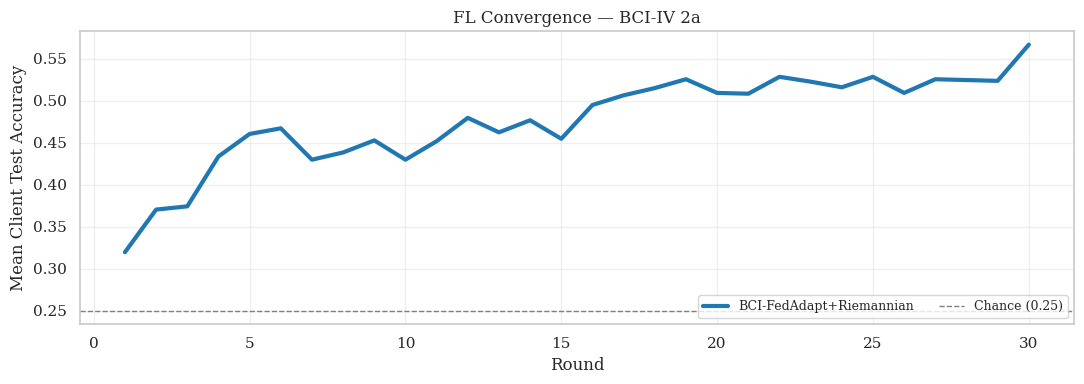

Saved: /mnt/user-data/outputs/convergence_2a.png


In [13]:
plot_convergence(results_2a, CFG_2A, 'BCI-IV 2a',
                 '/mnt/user-data/outputs/convergence_2a.png', STRATEGIES)

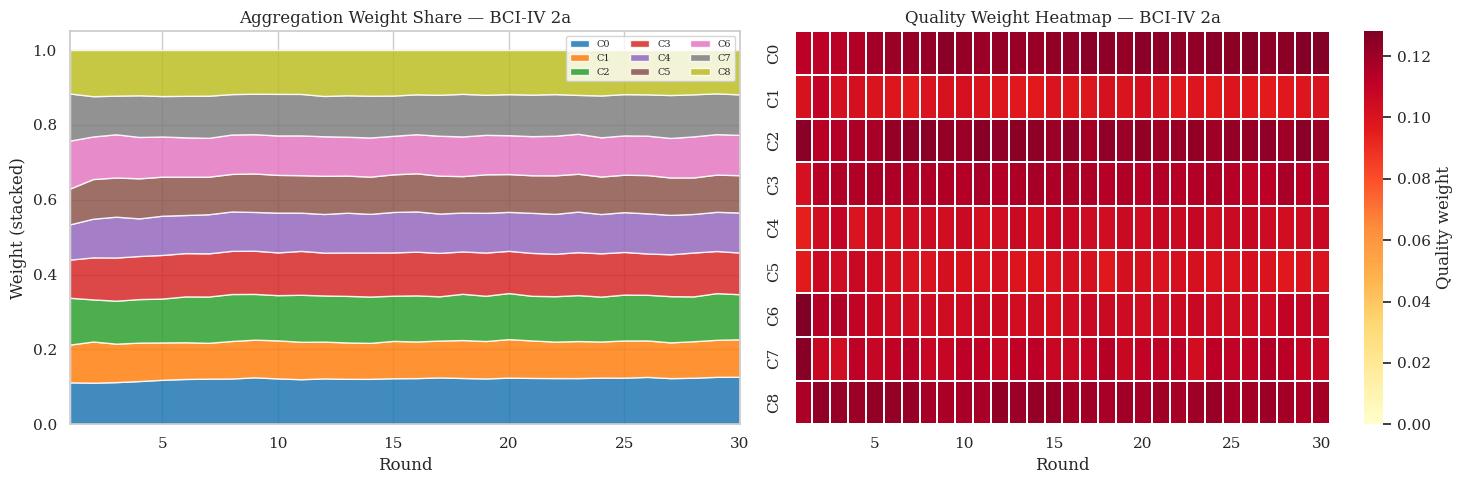

In [14]:
plot_quality_weights(results_2a, CFG_2A, 'BCI-IV 2a',
                     '/mnt/user-data/outputs/quality_weights_2a.png')

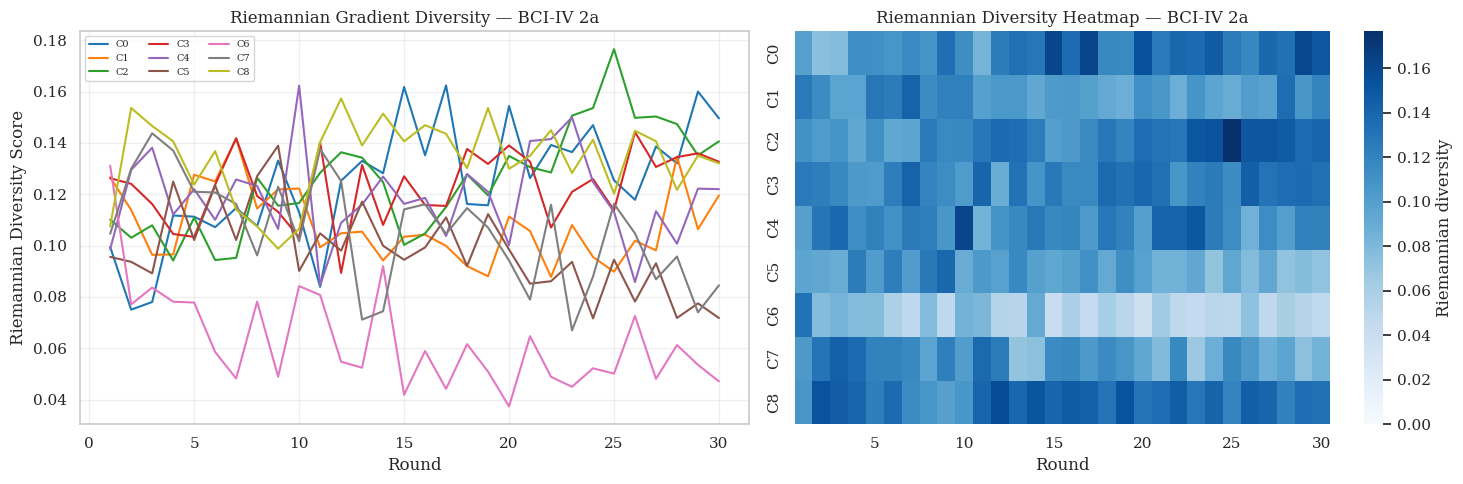

Saved: /mnt/user-data/outputs/riemannian_diversity_2a.png


In [15]:
# NEW: Riemannian diversity evolution
plot_riemannian_diversity(results_2a, CFG_2A, 'BCI-IV 2a',
                          '/mnt/user-data/outputs/riemannian_diversity_2a.png')

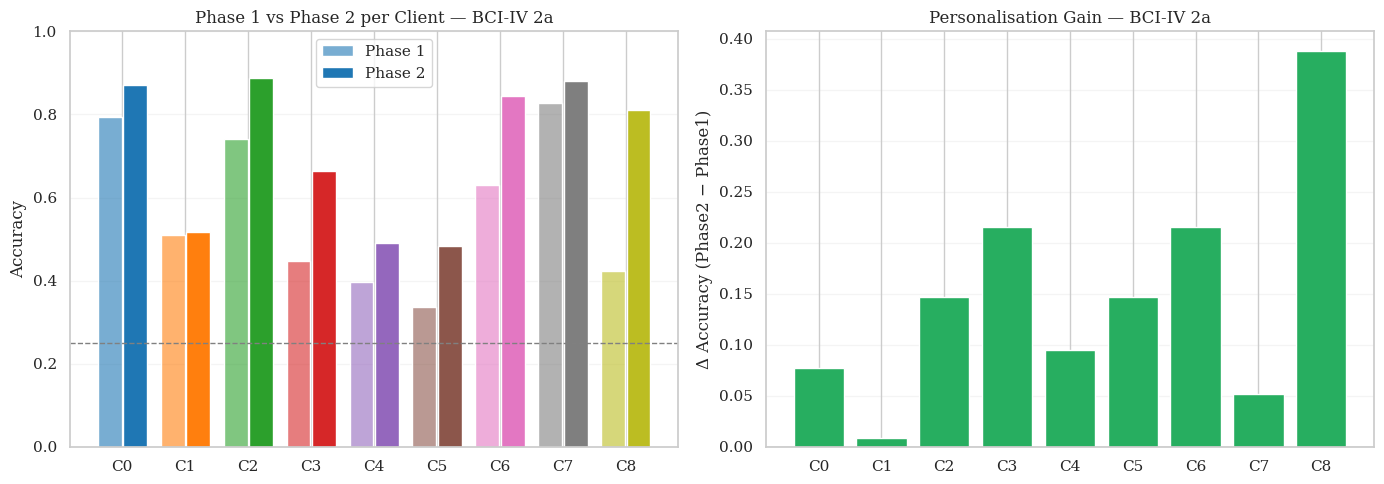

In [16]:
plot_personalisation_gain(results_2a, CFG_2A, 'BCI-IV 2a',
                          '/mnt/user-data/outputs/personalisation_2a.png')

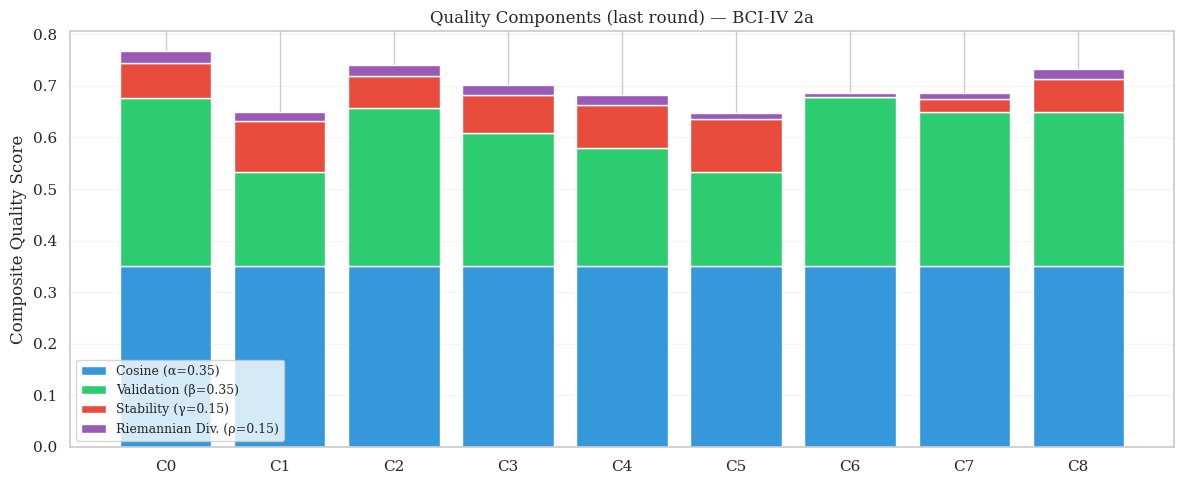

In [17]:
plot_quality_components(results_2a, CFG_2A, 'BCI-IV 2a',
                        '/mnt/user-data/outputs/quality_components_2a.png')

In [18]:
# Final evaluation — BCI-IV 2a
final_2a = {}
for strat in STRATEGIES:
    ps  = results_2a[strat]['final_personal_states']
    acc, yl, yp = eval_global(None, CFG_2A, client_data_2a, personal_states=ps)
    final_2a[strat] = (acc, yl, yp)
    print(f'{strat}: {acc:.4f}')
best_2a = max(final_2a, key=lambda s: final_2a[s][0])

BCI-FedAdapt+Riemannian: 0.7165


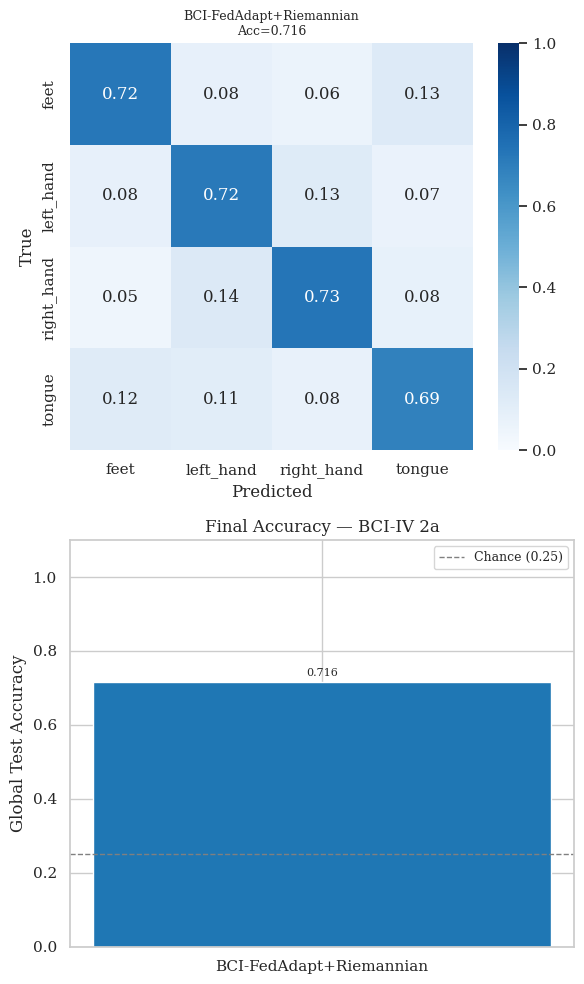

In [19]:
plot_eval(final_2a, STRATEGIES, CFG_2A, CLASS_NAMES_2A,
          'BCI-IV 2a', '/mnt/user-data/outputs/bci_iv_2a')

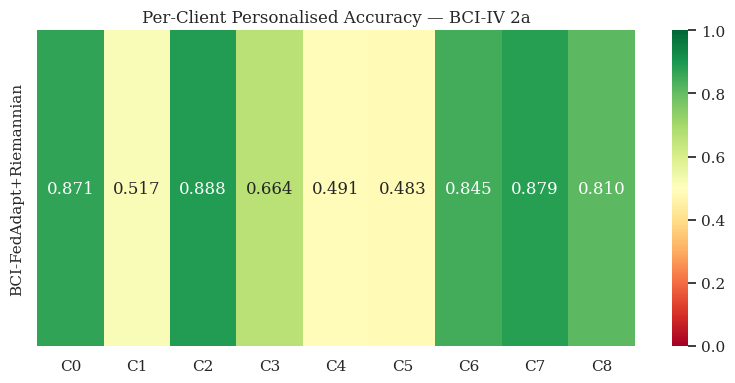

In [20]:
plot_per_client_heatmap(results_2a, STRATEGIES, CFG_2A, client_data_2a,
                        'BCI-IV 2a', '/mnt/user-data/outputs/per_client_2a.png')

In [21]:
print_summary(final_2a, STRATEGIES, CFG_2A, results_2a, 'BCI-IV 2a', best_2a)

# Classification report for best strategy
_, yl, yp = final_2a[best_2a]
print(classification_report(yl, yp, target_names=CLASS_NAMES_2A))


  SUMMARY — BCI-IV 2a
  BCI-FedAdapt+Riemannian           Acc=0.7165  P1=0.5670  P2=0.7165  Δchance=+0.4665  ← best

              precision    recall  f1-score   support

        feet       0.74      0.72      0.73       261
   left_hand       0.68      0.72      0.70       261
  right_hand       0.73      0.73      0.73       261
      tongue       0.71      0.69      0.70       261

    accuracy                           0.72      1044
   macro avg       0.72      0.72      0.72      1044
weighted avg       0.72      0.72      0.72      1044



---
# Part B — BCI-IV 2b  (9 subjects, 2-class Motor Imagery)

In [22]:
client_data_2b, N_TIMES_2B, CLASSES_2B = load_and_preprocess(CFG_2B)
CFG_2B['n_times'] = N_TIMES_2B
CLASS_NAMES_2B = [str(c) for c in CLASSES_2B]
print(f'\nBCI-IV 2b — {len(client_data_2b)} clients, {N_TIMES_2B} time points')

2026-03-12 08:19:03,349 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


Loading BCI-IV 2b [Riemannian alignment] ...


100%|█████████████████████████████████████| 34.2M/34.2M [00:00<00:00, 44.7GB/s]
SHA256 hash of downloaded file: 0da6e77ab0dab5b4aa1d2d5a6a542ac02f6768d3b7a76b0abe896ec1cf259919
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 18.6M/18.6M [00:00<00:00, 28.6GB/s]
SHA256 hash of downloaded file: 5effd365ae3733402286f2eea6b1ce482680a9f9ffc55c0b41bc63061a0161b5
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 33.1M/33.1M [00:00<00:00, 48.3GB/s]
SHA256 hash of downloaded file: 1c4ace3eee8d72ca184fa6995a9466939b71175b8b3a129bdaa838a85adf6473
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|████████████████████████████████

  Raw shape: (6520, 3, 1001)  Classes: [np.str_('left_hand'), np.str_('right_hand')]
  Client 00: train=576  test=144
  Client 01: train=544  test=136
  Client 02: train=576  test=144
  Client 03: train=592  test=148
  Client 04: train=592  test=148
  Client 05: train=576  test=144
  Client 06: train=576  test=144
  Client 07: train=608  test=152
  Client 08: train=576  test=144

BCI-IV 2b — 9 clients, 1001 time points


In [23]:
# Run BCI-FedAdapt+Riemannian on BCI-IV 2b
results_2b = {}
results_2b['BCI-FedAdapt+Riemannian'] = run_bci_fedadapt(CFG_2B, client_data_2b)


------------------------------------------------------------------------
  BCI-FedAdapt+Riemannian [RA align | Riemannian agg]
  Phase1: 30 rounds  Phase2: 40 epochs
------------------------------------------------------------------------
  [Phase 1] Federated training with Riemannian aggregation ...
  Round   1  loss=0.5821  acc=0.6158  top=C6(0.124)  riem_div=0.1111
  Round   5  loss=0.5558  acc=0.6411  top=C8(0.122)  riem_div=0.1111
  Round  10  loss=0.5450  acc=0.6810  top=C6(0.127)  riem_div=0.1111
  Round  15  loss=0.5390  acc=0.6526  top=C3(0.127)  riem_div=0.1111
  Round  20  loss=0.5360  acc=0.6687  top=C3(0.125)  riem_div=0.1111
  Round  25  loss=0.5358  acc=0.6764  top=C3(0.123)  riem_div=0.1111
  Round  30  loss=0.5340  acc=0.7086  top=C8(0.123)  riem_div=0.1111

  [Phase 2] Local personalisation (40 epochs)...
  Client 00: before=0.7847  after=0.7708  Δ=-0.0139
  Client 01: before=0.5588  after=0.4779  Δ=-0.0809
  Client 02: before=0.5278  after=0.5347  Δ=+0.0069
  Client

## Analysis — BCI-IV 2b

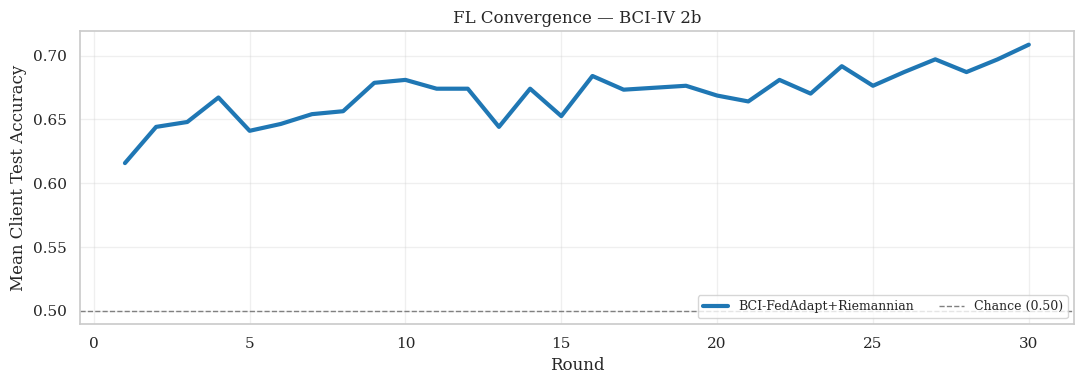

Saved: /mnt/user-data/outputs/convergence_2b.png


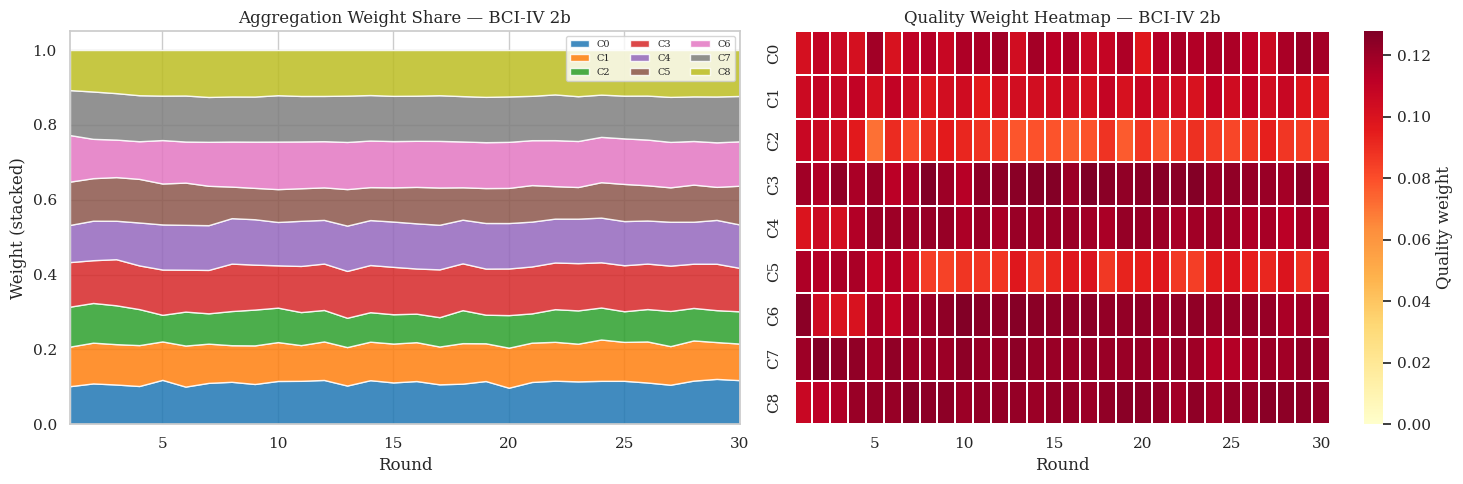

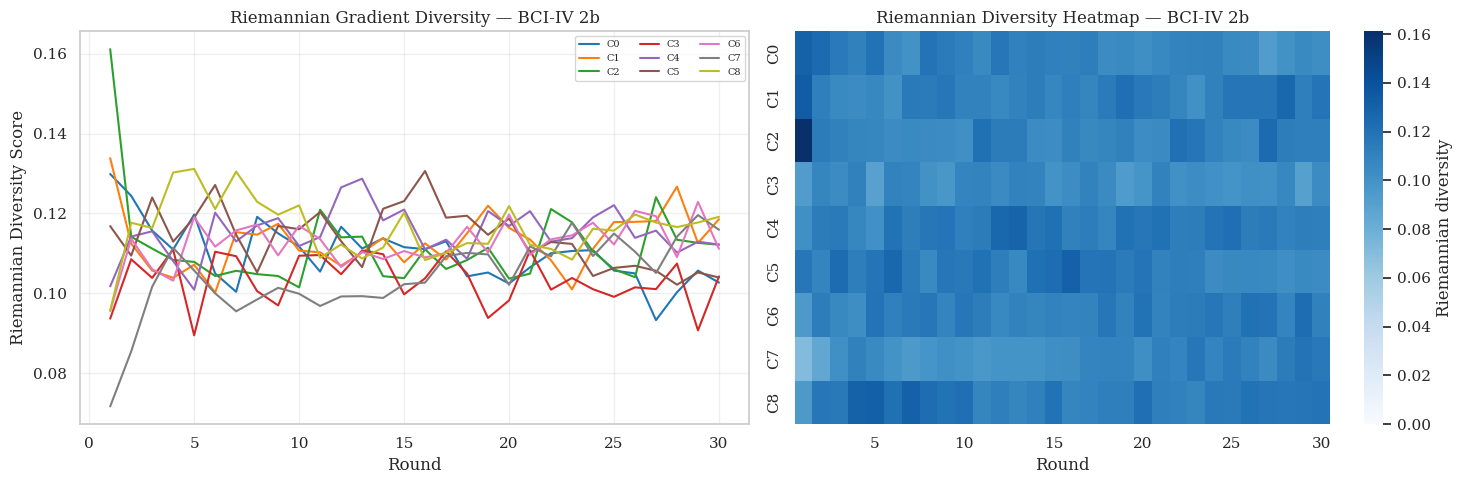

Saved: /mnt/user-data/outputs/riemannian_diversity_2b.png


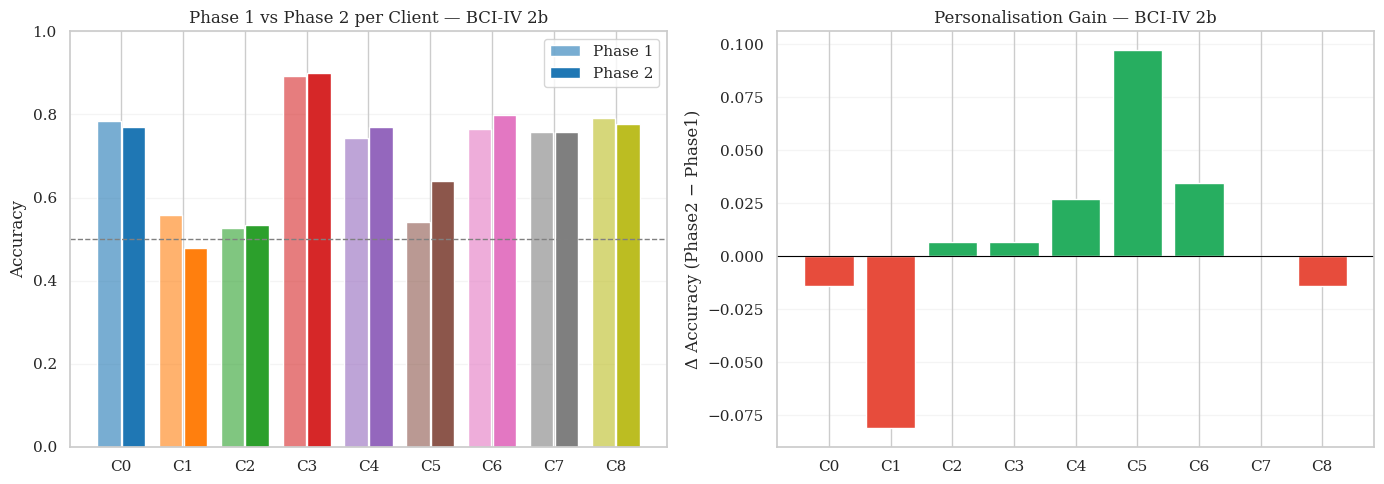

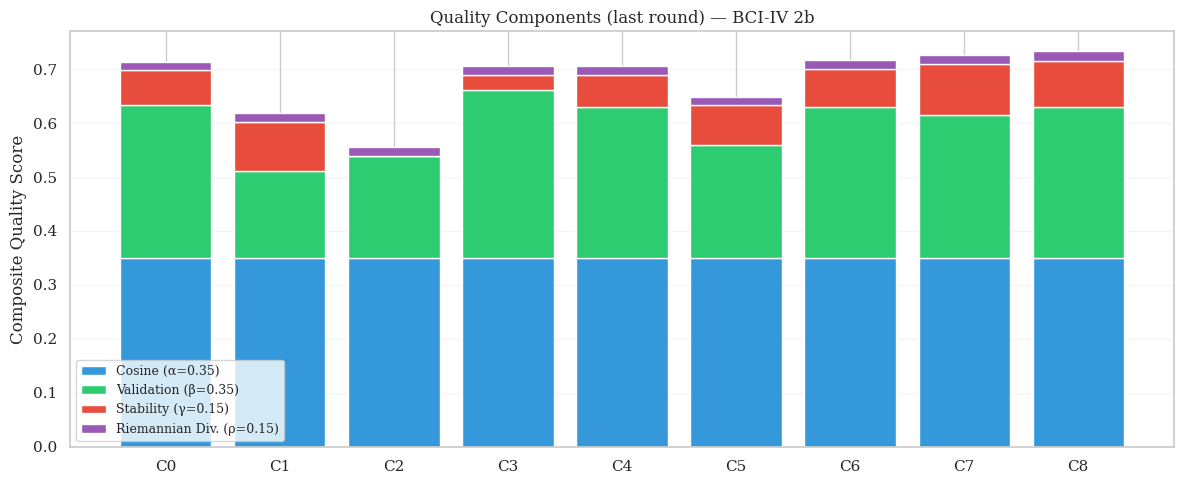

In [24]:
plot_convergence(results_2b, CFG_2B, 'BCI-IV 2b',
                 '/mnt/user-data/outputs/convergence_2b.png', STRATEGIES)
plot_quality_weights(results_2b, CFG_2B, 'BCI-IV 2b',
                     '/mnt/user-data/outputs/quality_weights_2b.png')
plot_riemannian_diversity(results_2b, CFG_2B, 'BCI-IV 2b',
                          '/mnt/user-data/outputs/riemannian_diversity_2b.png')
plot_personalisation_gain(results_2b, CFG_2B, 'BCI-IV 2b',
                          '/mnt/user-data/outputs/personalisation_2b.png')
plot_quality_components(results_2b, CFG_2B, 'BCI-IV 2b',
                        '/mnt/user-data/outputs/quality_components_2b.png')

BCI-FedAdapt+Riemannian: 0.7163


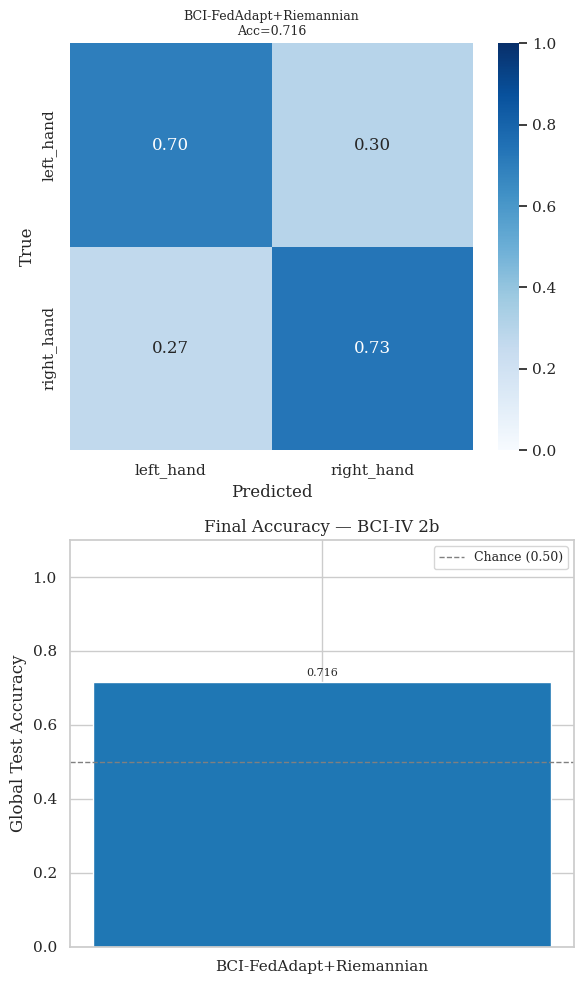

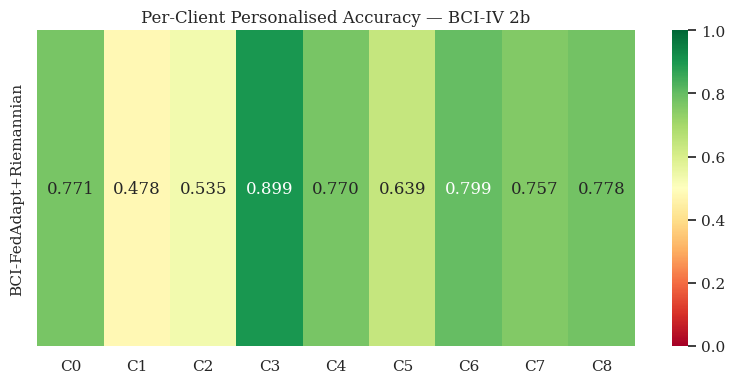


  SUMMARY — BCI-IV 2b
  BCI-FedAdapt+Riemannian           Acc=0.7163  P1=0.7086  P2=0.7163  Δchance=+0.2163  ← best

              precision    recall  f1-score   support

   left_hand       0.72      0.70      0.71       652
  right_hand       0.71      0.73      0.72       652

    accuracy                           0.72      1304
   macro avg       0.72      0.72      0.72      1304
weighted avg       0.72      0.72      0.72      1304



In [25]:
# Final evaluation — BCI-IV 2b
final_2b = {}
for strat in STRATEGIES:
    ps  = results_2b[strat]['final_personal_states']
    acc, yl, yp = eval_global(None, CFG_2B, client_data_2b, personal_states=ps)
    final_2b[strat] = (acc, yl, yp)
    print(f'{strat}: {acc:.4f}')
best_2b = max(final_2b, key=lambda s: final_2b[s][0])

plot_eval(final_2b, STRATEGIES, CFG_2B, CLASS_NAMES_2B,
          'BCI-IV 2b', '/mnt/user-data/outputs/bci_iv_2b')
plot_per_client_heatmap(results_2b, STRATEGIES, CFG_2B, client_data_2b,
                        'BCI-IV 2b', '/mnt/user-data/outputs/per_client_2b.png')
print_summary(final_2b, STRATEGIES, CFG_2B, results_2b, 'BCI-IV 2b', best_2b)
_, yl, yp = final_2b[best_2b]
print(classification_report(yl, yp, target_names=CLASS_NAMES_2B))

---
# Cross-Dataset Comparison & Riemannian Manifold Summary

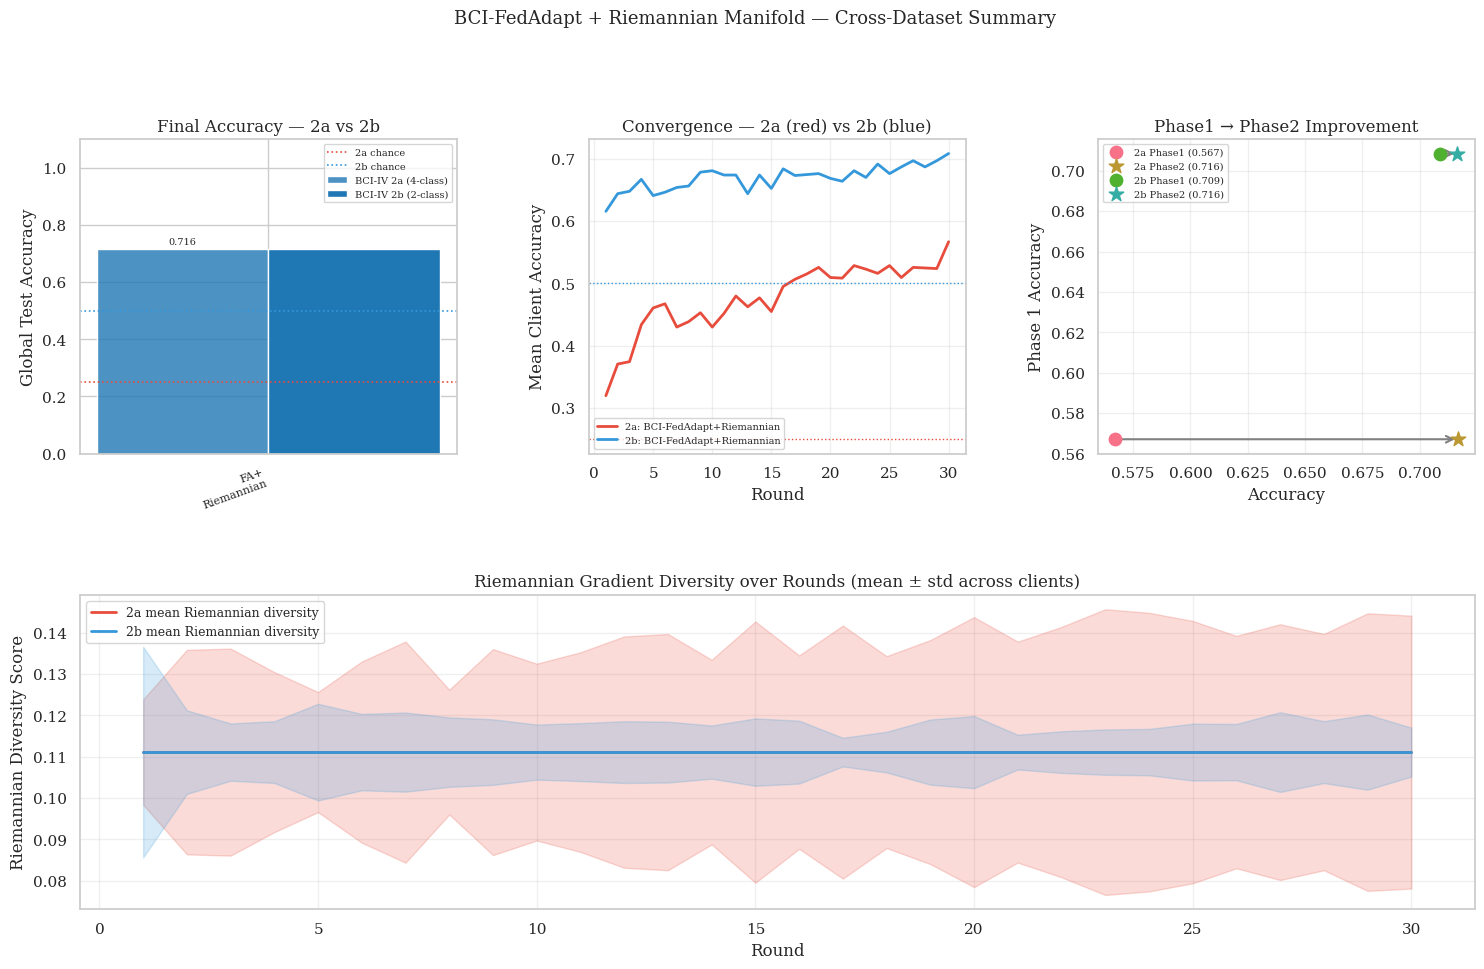

Cross-dataset summary saved.


In [26]:
# Cross-dataset comparison with Riemannian diversity overlay
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Top left: bar chart final accuracy ──
ax0 = fig.add_subplot(gs[0, 0])
x   = np.arange(len(STRATEGIES))
w   = 0.35
accs_2a = [final_2a[s][0] for s in STRATEGIES]
accs_2b = [final_2b[s][0] for s in STRATEGIES]
pal     = sns.color_palette('tab10', len(STRATEGIES))
ax0.bar(x-w/2, accs_2a, w, label='BCI-IV 2a (4-class)',
        color=[p+(0.8,) for p in pal], edgecolor='white')
ax0.bar(x+w/2, accs_2b, w, label='BCI-IV 2b (2-class)',
        color=pal, edgecolor='white')
ax0.axhline(0.25, ls=':', color='#e74c3c', lw=1.2, label='2a chance')
ax0.axhline(0.50, ls=':', color='#3498db', lw=1.2, label='2b chance')
ax0.set_xticks(x)
ax0.set_xticklabels([s.replace('BCI-FedAdapt+', 'FA+\n') for s in STRATEGIES],
                    rotation=20, ha='right', fontsize=8)
ax0.set_ylabel('Global Test Accuracy'); ax0.set_ylim(0, 1.1)
ax0.set_title('Final Accuracy — 2a vs 2b'); ax0.legend(fontsize=7)
for bar, a in zip(ax0.patches[:len(STRATEGIES)], accs_2a):
    ax0.text(bar.get_x()+bar.get_width()/2, a+0.01, f'{a:.3f}',
             ha='center', va='bottom', fontsize=7)

# ── Top middle: convergence ──
ax1 = fig.add_subplot(gs[0, 1])
rounds = np.arange(1, CFG_2A['num_rounds'] + 1)
for tag, res, col in [('2a', results_2a, '#e74c3c'), ('2b', results_2b, '#3498db')]:
    for s in STRATEGIES:
        ax1.plot(rounds, res[s]['history'], color=col, lw=2, label=f'{tag}: {s}')
ax1.axhline(0.25, ls=':', color='#e74c3c', lw=1)
ax1.axhline(0.50, ls=':', color='#3498db', lw=1)
ax1.set_xlabel('Round'); ax1.set_ylabel('Mean Client Accuracy')
ax1.set_title('Convergence — 2a (red) vs 2b (blue)')
ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

# ── Top right: Phase1 vs Phase2 improvement ──
ax2 = fig.add_subplot(gs[0, 2])
for (tag, results, cfg_) in [('2a', results_2a, CFG_2A), ('2b', results_2b, CFG_2B)]:
    for s in STRATEGIES:
        p1 = results[s]['mean_acc_phase1']
        p2 = results[s]['mean_acc_phase2']
        ax2.annotate('', xy=(p2, p1), xytext=(p1, p1),
                     arrowprops=dict(arrowstyle='->', color='grey', lw=1.5))
        ax2.scatter([p1], [p1], marker='o', s=80, zorder=5, label=f'{tag} Phase1 ({p1:.3f})')
        ax2.scatter([p2], [p1], marker='*', s=120, zorder=5, label=f'{tag} Phase2 ({p2:.3f})')
ax2.set_xlabel('Accuracy'); ax2.set_ylabel('Phase 1 Accuracy')
ax2.set_title('Phase1 → Phase2 Improvement')
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

# ── Bottom: Riemannian diversity over rounds (both datasets) ──
ax3 = fig.add_subplot(gs[1, :])
key = STRATEGIES[0]
for (tag, results, col) in [('2a', results_2a, '#e74c3c'), ('2b', results_2b, '#3498db')]:
    diag_log = results[key]['diag_log']
    riem_mean = np.array([d['riemann'].mean() for d in diag_log])
    riem_std  = np.array([d['riemann'].std()  for d in diag_log])
    ax3.plot(rounds, riem_mean, color=col, lw=2, label=f'{tag} mean Riemannian diversity')
    ax3.fill_between(rounds, riem_mean - riem_std, riem_mean + riem_std,
                     alpha=0.2, color=col)
ax3.set_xlabel('Round'); ax3.set_ylabel('Riemannian Diversity Score')
ax3.set_title('Riemannian Gradient Diversity over Rounds (mean ± std across clients)')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.suptitle('BCI-FedAdapt + Riemannian Manifold — Cross-Dataset Summary', fontsize=13, y=1.01)
plt.savefig('/mnt/user-data/outputs/cross_dataset_riemannian.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cross-dataset summary saved.')

In [27]:
# ── Final printed summary ──────────────────────────────────────────────────────
print('\n' + '='*72)
print('  FINAL RESULTS SUMMARY — BCI-FedAdapt + Riemannian Manifold')
print('='*72)
for ds_tag, final_, cfg_, results_ in [
        ('BCI-IV 2a (4-class)', final_2a, CFG_2A, results_2a),
        ('BCI-IV 2b (2-class)', final_2b, CFG_2B, results_2b)]:
    chance = 1.0 / cfg_['n_classes']
    print(f'\n  {ds_tag}')
    print(f'  {"─"*60}')
    for s in STRATEGIES:
        acc = final_[s][0]
        p1  = results_[s]['mean_acc_phase1']
        p2  = results_[s]['mean_acc_phase2']
        riemann_q = np.mean([d['riemann'].mean() for d in results_[s]['diag_log']])
        print(f'  Strategy : {s}')
        print(f'  Phase 1  : {p1:.4f}   Phase 2: {p2:.4f}   Global: {acc:.4f}')
        print(f'  Δ chance : {acc - chance:+.4f}   Mean Riemannian diversity: {riemann_q:.5f}')
print('\n' + '='*72)


  FINAL RESULTS SUMMARY — BCI-FedAdapt + Riemannian Manifold

  BCI-IV 2a (4-class)
  ────────────────────────────────────────────────────────────
  Strategy : BCI-FedAdapt+Riemannian
  Phase 1  : 0.5670   Phase 2: 0.7165   Global: 0.7165
  Δ chance : +0.4665   Mean Riemannian diversity: 0.11111

  BCI-IV 2b (2-class)
  ────────────────────────────────────────────────────────────
  Strategy : BCI-FedAdapt+Riemannian
  Phase 1  : 0.7086   Phase 2: 0.7163   Global: 0.7163
  Δ chance : +0.2163   Mean Riemannian diversity: 0.11111

